<a href="https://colab.research.google.com/github/Taqi05/ChurnPrediction/blob/main/UAS_Progress_Bengkod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Bengkel Koding Data Science
## **Customer Churn Prediction — Sales and Marketing Dataset**

Nama : Muhamad Taqi

NIM : A11.2023.14888

##  Setup & Import Library

In [ ]:
# Install library yang mungkin belum tersedia di Colab
!pip install kaggle opendatasets -q

# Data Manipulation
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# === Preprocessing ===
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# === Model Konvensional ===
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# === Ensemble Bagging ===
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

# === Ensemble Voting ===
from sklearn.ensemble import VotingClassifier

# === Evaluasi ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)


In [ ]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')

# **1.  EXPLORATORY DATA ANALYSIS (EDA)**

> Mengolah data dan memvalidasi data


### 1.1 Tampilan Awal Dataset

In [ ]:
# 5 BARIS PERTAMA
# Melihat format data, tipe kolom, dan nilai awal
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [ ]:
# INFORMASI DATASET
# Mengetahui tipe data, jumlah non-null, dan memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [ ]:
# STATISTIK DESKRIPTIF
# Memahami distribusi (mean, std, min, max, quartile) untuk mendeteksi potensi outlier dan skewness

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,15000.0,NaN,NaN,NaN,17500.5,4330.271354,10001.0,13750.75,17500.5,21250.25,25000.0
gender,14262,3,Male,6844,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,13800.0,NaN,NaN,NaN,35.203913,10.334384,-4.0,28.0,35.0,42.0,95.0
country,15000,5,Germany,3072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,15000,7,London,2236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,15000,1000,2024-09-20 00:00:00,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_purchase_date,15000,800,2025-01-17 00:00:00,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acquisition_channel,15000,5,Organic,3055,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,15000,3,Tablet,5043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription_type,15000,2,Monthly,7666,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Analisis Missing Value

RINGKASAN MISSING VALUE
                    Jumlah Missing  Persentase (%)
coupon_code                   6133           40.89
age                           1200            8.00
total_spent                   1050            7.00
gender                         738            4.92
satisfaction_score             702            4.68


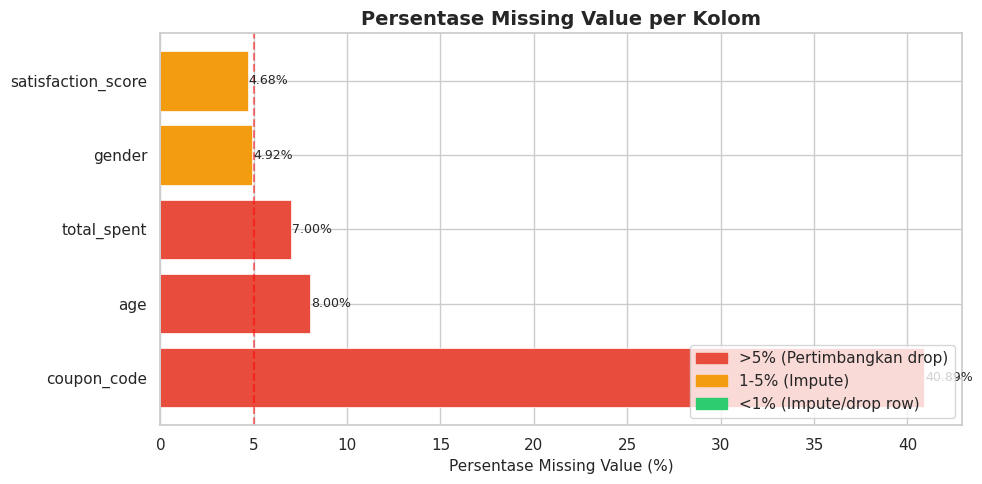

In [ ]:
# ANALISIS MISSING VALUE
# Missing value dapat menyebabkan error pada model atau bias jika tidak ditangani.
# Persentase membantu menentukan strategi penanganan (impute vs drop)


missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)
missing_df    = pd.DataFrame({
    'Jumlah Missing'    : missing_count,
    'Persentase (%)' : missing_pct
}).sort_values('Persentase (%)', ascending=False)

missing_df = missing_df[missing_df['Jumlah Missing'] > 0]


print('RINGKASAN MISSING VALUE')

print(missing_df.to_string())

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
if len(missing_df) > 0:
    colors = ['#e74c3c' if x > 5 else '#f39c12' if x > 1 else '#2ecc71'
              for x in missing_df['Persentase (%)']]
    bars = ax.barh(missing_df.index, missing_df['Persentase (%)'],
                   color=colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, missing_df['Persentase (%)']):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', fontsize=9)
    ax.axvline(5, color='red', linestyle='--', alpha=0.5, label='Threshold 5%')
    ax.set_xlabel('Persentase Missing Value (%)', fontsize=11)
    ax.set_title('Persentase Missing Value per Kolom', fontsize=14, fontweight='bold')
    ax.legend()
    red_patch   = mpatches.Patch(color='#e74c3c', label='>5% (Pertimbangkan drop)')
    orange_patch= mpatches.Patch(color='#f39c12', label='1-5% (Impute)')
    green_patch = mpatches.Patch(color='#2ecc71', label='<1% (Impute/drop row)')
    ax.legend(handles=[red_patch, orange_patch, green_patch], loc='lower right')
else:
    ax.text(0.5, 0.5, 'Tidak ada Missing Value!', ha='center', va='center',
            fontsize=16, color='green', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('eda_missing_value.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.3 Distribusi Variabel Target (Churn)

DISTRIBUSI VARIABEL TARGET: CHURN
                                                  
Tidak Churn (0) : 12,702 (84.68%)
Churn      (1) : 2,298 (15.32%)
Rasio (Non-Churn : Churn) = 5.5 : 1


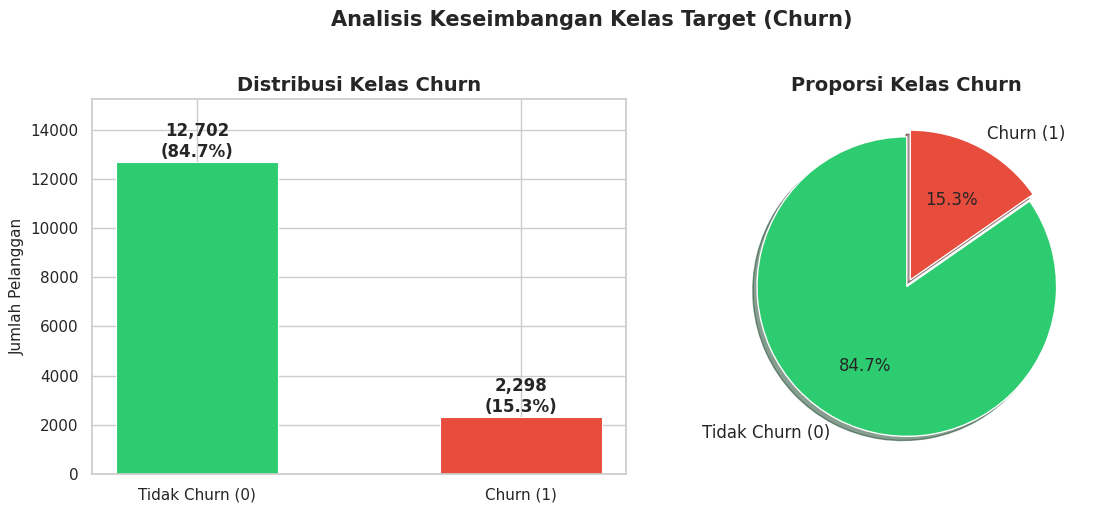

DATASET IMBALANCED!
   Strategi yang akan digunakan: SMOTE (Synthetic Minority Oversampling Technique)
   Alasan memilih SMOTE vs cara lain:
   - SMOTE membuat data sintetis berdasarkan interpolasi, bukan duplikasi
   - Lebih baik dari oversampling random (tidak mudah overfit)
   - Lebih baik dari undersampling (tidak membuang data berharga)
   - SMOTE diterapkan HANYA pada training set, bukan test set!


In [ ]:
# DISTRIBUSI VARIABEL TARGET
# Mengetahui apakah data imbalanced (tidak seimbang).
# Jika rasio kelas sangat timpang (misal 90:10), model cenderung bias ke kelas mayoritas -> perlu SMOTE atau class_weight='balanced'


churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100


print('DISTRIBUSI VARIABEL TARGET: CHURN')
print(' ' * 50)
print(f"Tidak Churn (0) : {churn_counts[0]:,} ({churn_pct[0]:.2f}%)")
print(f"Churn      (1) : {churn_counts[1]:,} ({churn_pct[1]:.2f}%)")
print(f"Rasio (Non-Churn : Churn) = {churn_pct[0]/churn_pct[1]:.1f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
bars   = axes[0].bar(['Tidak Churn (0)', 'Churn (1)'],
                     churn_counts.values, color=colors,
                     edgecolor='white', linewidth=0.8, width=0.5)
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom',
                 fontweight='bold', fontsize=12)
axes[0].set_title('Distribusi Kelas Churn', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan', fontsize=11)
axes[0].set_ylim(0, max(churn_counts.values) * 1.2)

# Pie chart
axes[1].pie(churn_counts.values, labels=['Tidak Churn (0)', 'Churn (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0, 0.05), shadow=True,
            textprops={'fontsize': 12})
axes[1].set_title('Proporsi Kelas Churn', fontsize=14, fontweight='bold')

plt.suptitle('Analisis Keseimbangan Kelas Target (Churn)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Keputusan imbalance
imbalance_ratio = churn_pct[0] / churn_pct[1]
if imbalance_ratio > 3:
    print('DATASET IMBALANCED!')
    print('   Strategi yang akan digunakan: SMOTE (Synthetic Minority Oversampling Technique)')
    print('   Alasan memilih SMOTE vs cara lain:')
    print('   - SMOTE membuat data sintetis berdasarkan interpolasi, bukan duplikasi')
    print('   - Lebih baik dari oversampling random (tidak mudah overfit)')
    print('   - Lebih baik dari undersampling (tidak membuang data berharga)')
    print('   - SMOTE diterapkan HANYA pada training set, bukan test set!')
else:
    print(' Dataset relatif seimbang. SMOTE opsional.')

### 1.4 Analisis Distribusi Fitur Numerik

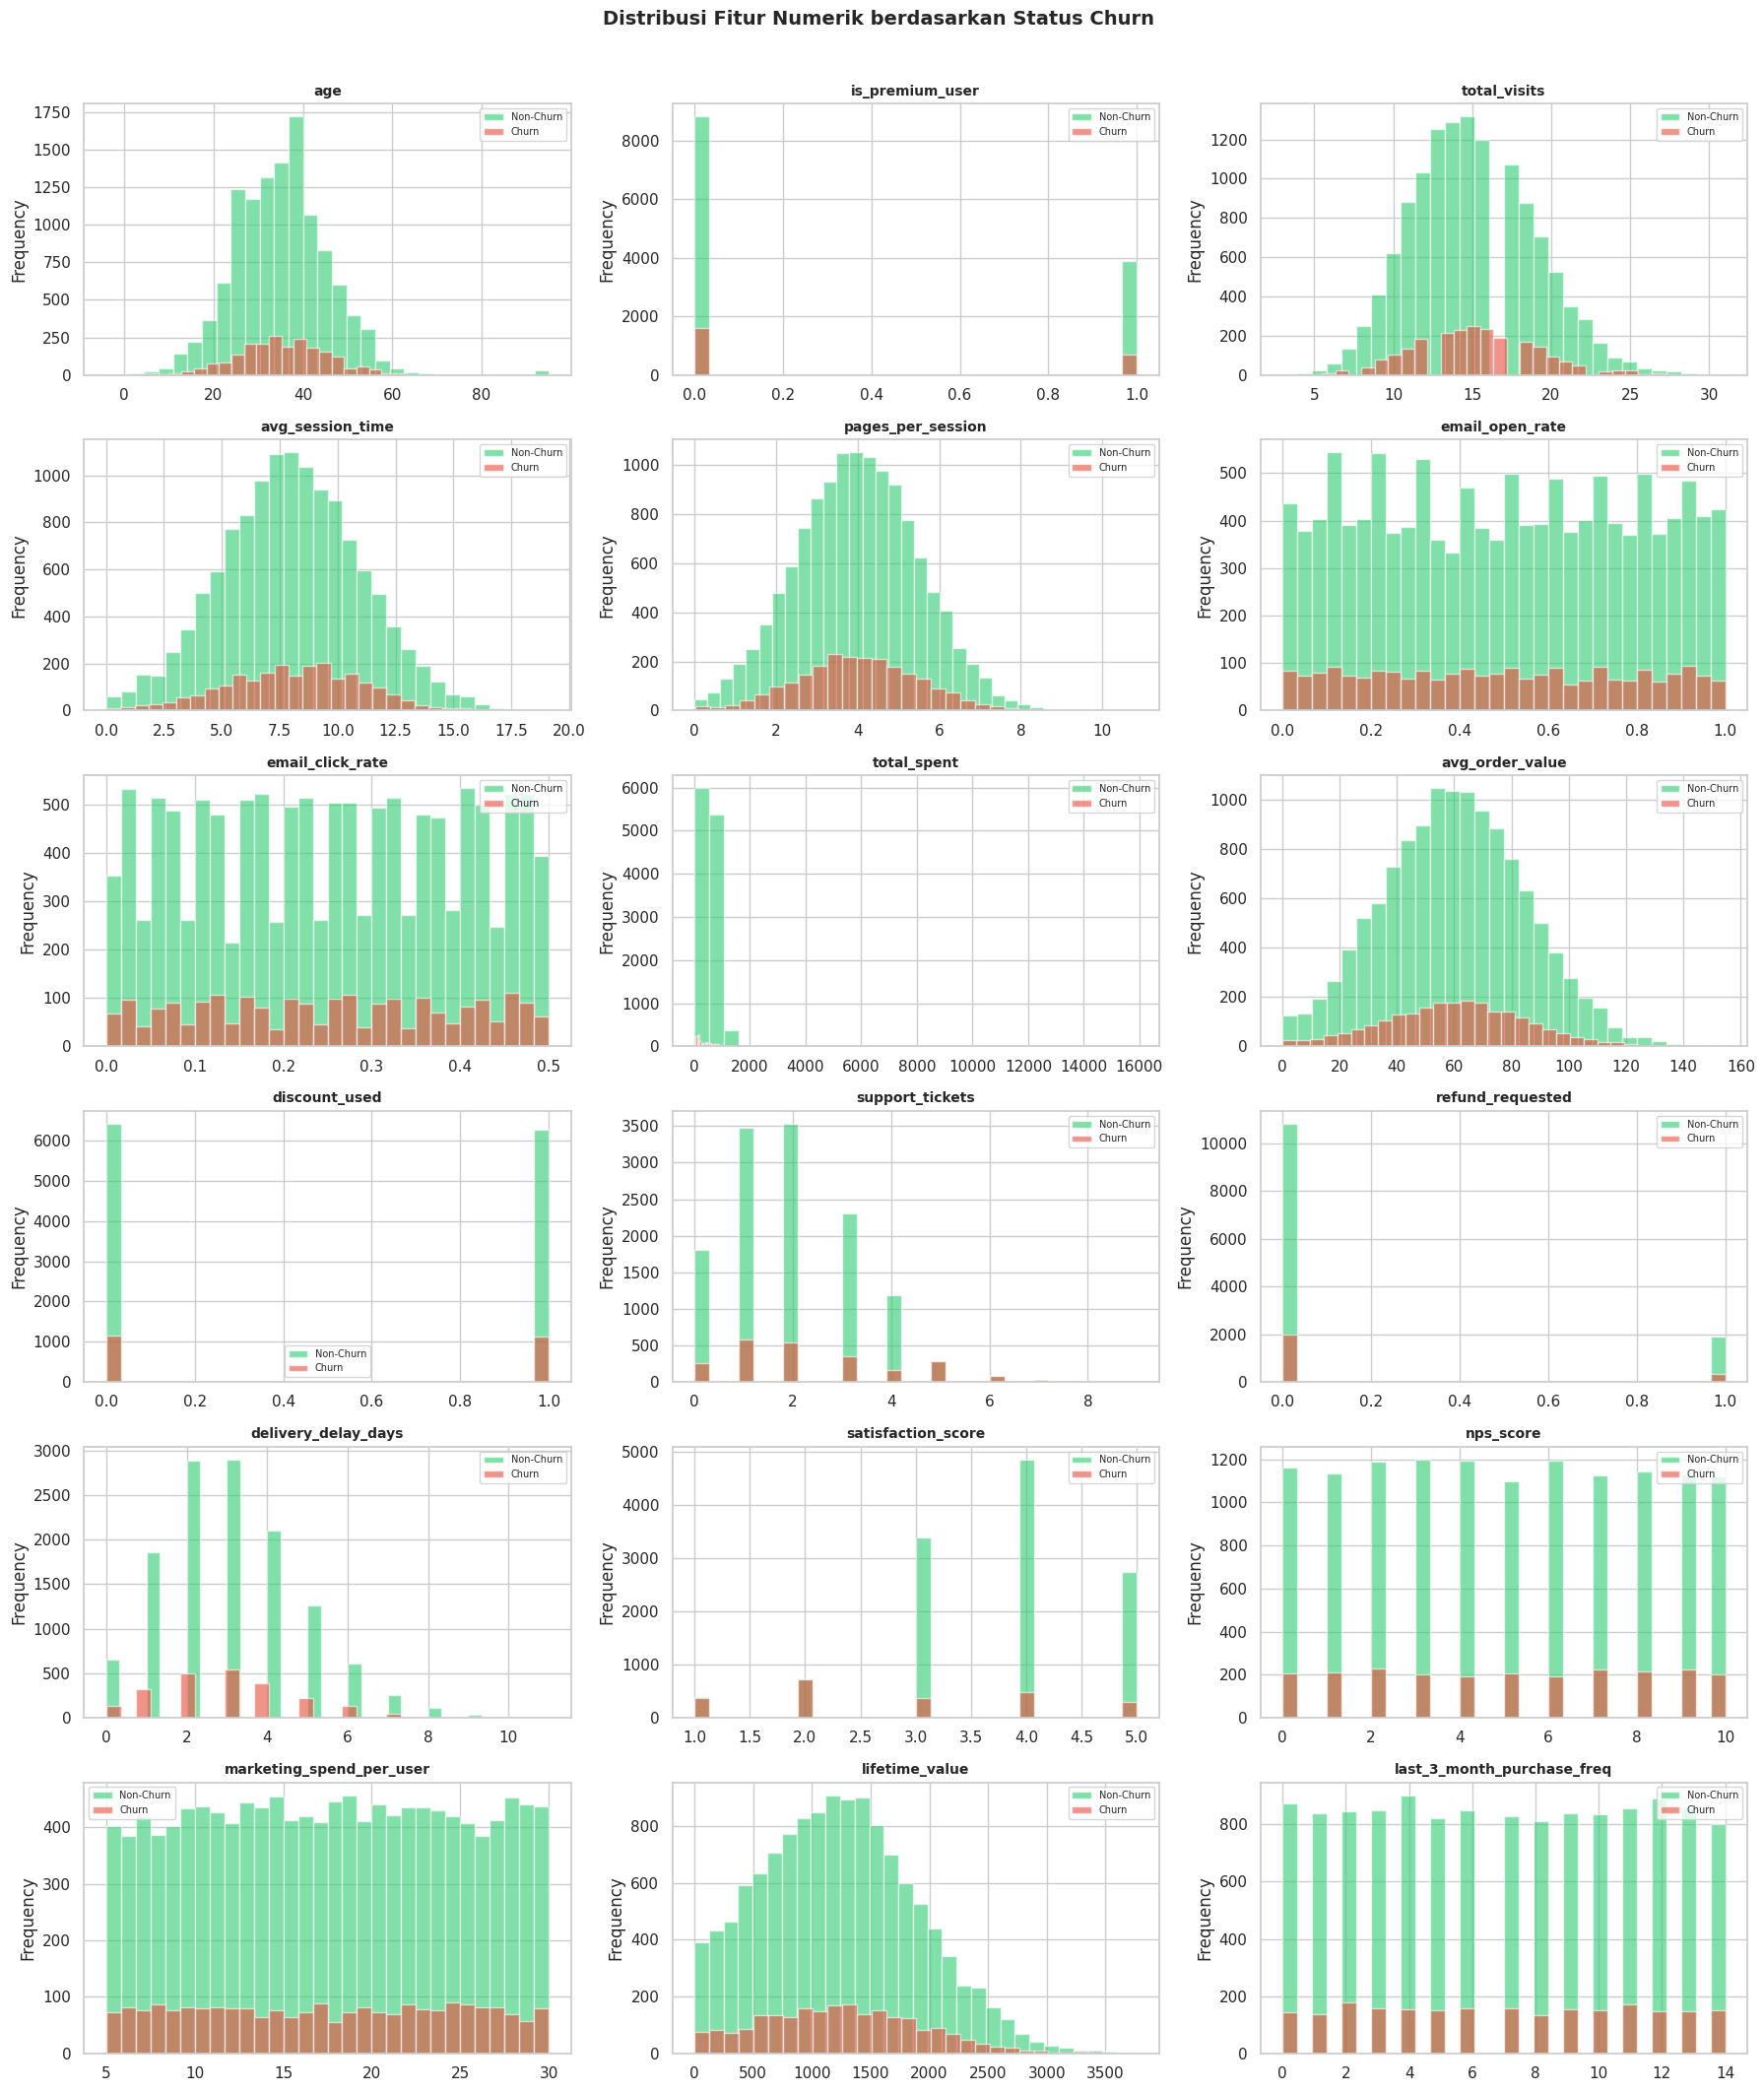

In [ ]:
# DISTRIBUSI FITUR NUMERIK
# Memahami skewness dan potensi outlier pada setiap fitur numerik

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['customer_id', 'churn']]

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    # Histogram dengan KDE, dibedakan berdasarkan churn
    df[df['churn'] == 0][col].dropna().plot.hist(ax=ax, alpha=0.6, bins=30,
                                                   color='#2ecc71', label='Non-Churn')
    df[df['churn'] == 1][col].dropna().plot.hist(ax=ax, alpha=0.6, bins=30,
                                                   color='#e74c3c', label='Churn')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel('')

# Sembunyikan subplot kosong
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik berdasarkan Status Churn',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.5 Heatmap Korelasi

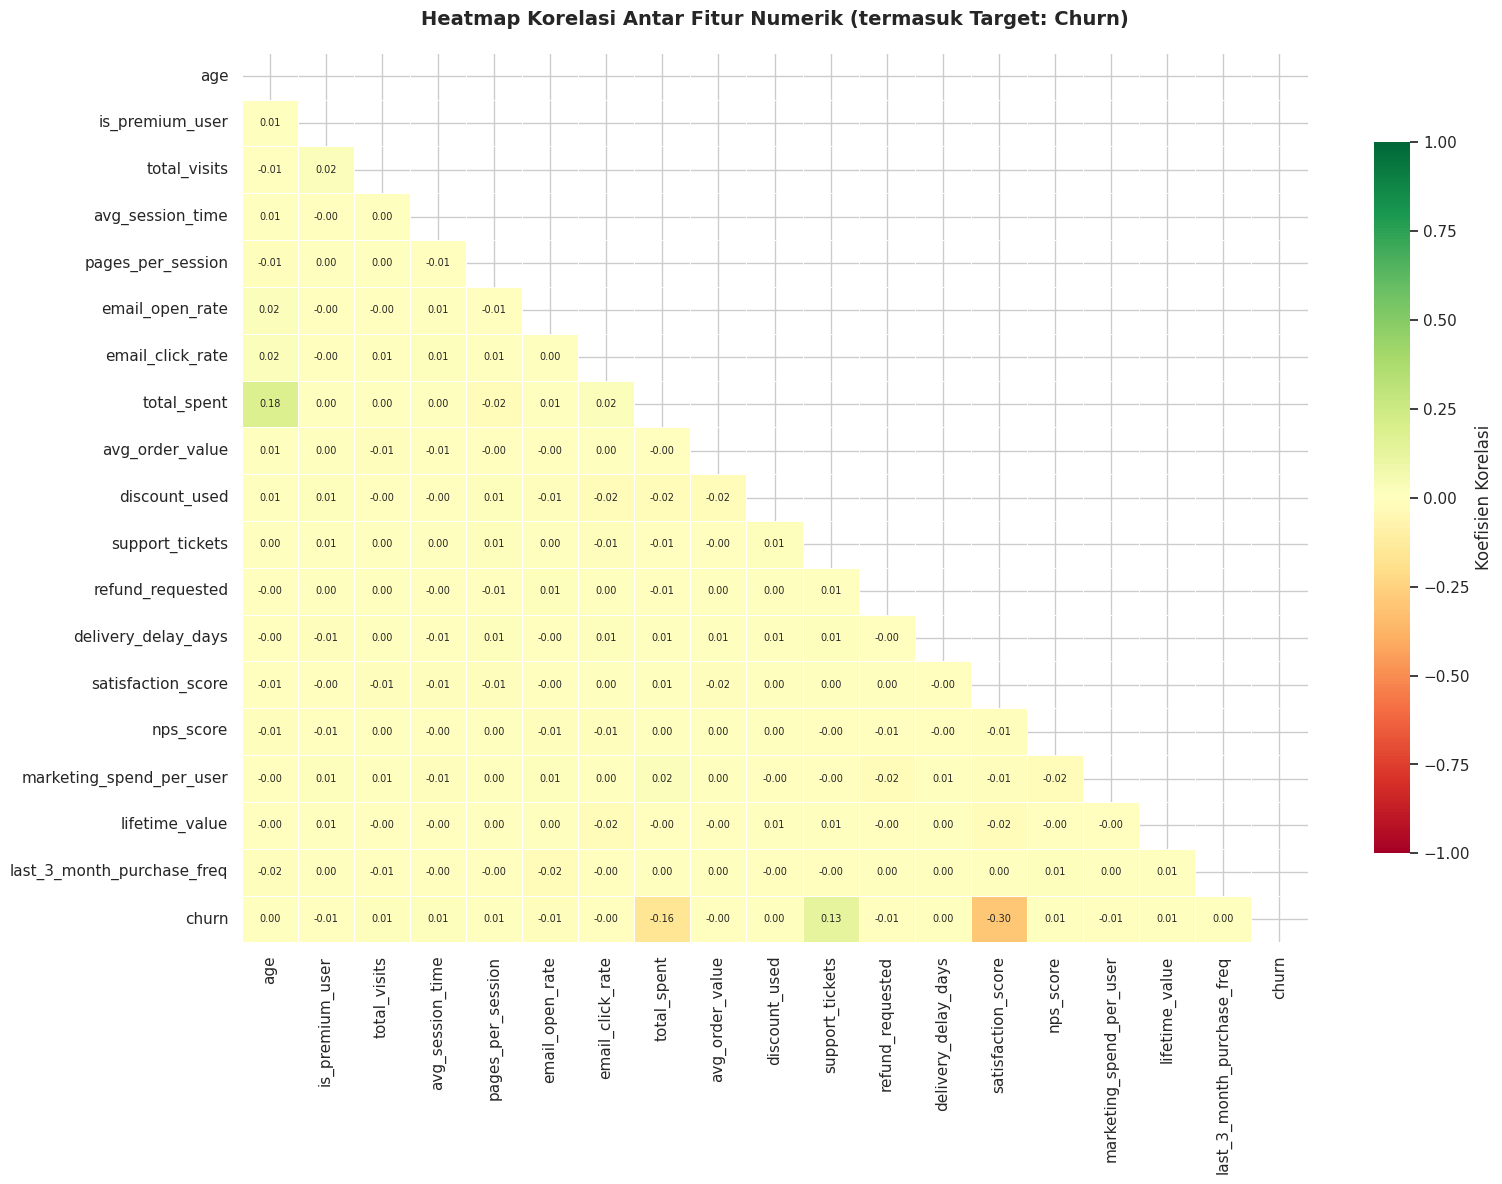

TOP 10 FITUR BERKORELASI DENGAN CHURN:
satisfaction_score          0.303588
total_spent                 0.163279
support_tickets             0.127910
total_visits                0.013212
avg_session_time            0.012198
email_open_rate             0.008439
marketing_spend_per_user    0.007315
refund_requested            0.006959
lifetime_value              0.006250
pages_per_session           0.005871
Insight: Fitur dengan |korelasi| > 0.1 dengan churn memiliki potensi prediktif yang baik.


In [ ]:
# HEATMAP KORELASI
# Mengidentifikasi:
# Fitur yang berkorelasi tinggi dengan target (churn) -> penting
# Multikolinearitas antar fitur -> bisa menyebabkan masalah pada model seperti Logistic Regression


corr_cols = df[num_cols + ['churn']].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask    = np.triu(np.ones_like(corr_cols, dtype=bool))  # Sembunyikan segitiga atas

sns.heatmap(
    corr_cols,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Koefisien Korelasi'},
    ax=ax,
    annot_kws={'size': 7}
)

ax.set_title('Heatmap Korelasi Antar Fitur Numerik (termasuk Target: Churn)',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Korelasi dengan target
corr_target = corr_cols['churn'].drop('churn').abs().sort_values(ascending=False)
print('TOP 10 FITUR BERKORELASI DENGAN CHURN:')
print(corr_target.head(10).to_string())
print('Insight: Fitur dengan |korelasi| > 0.1 dengan churn memiliki potensi prediktif yang baik.')

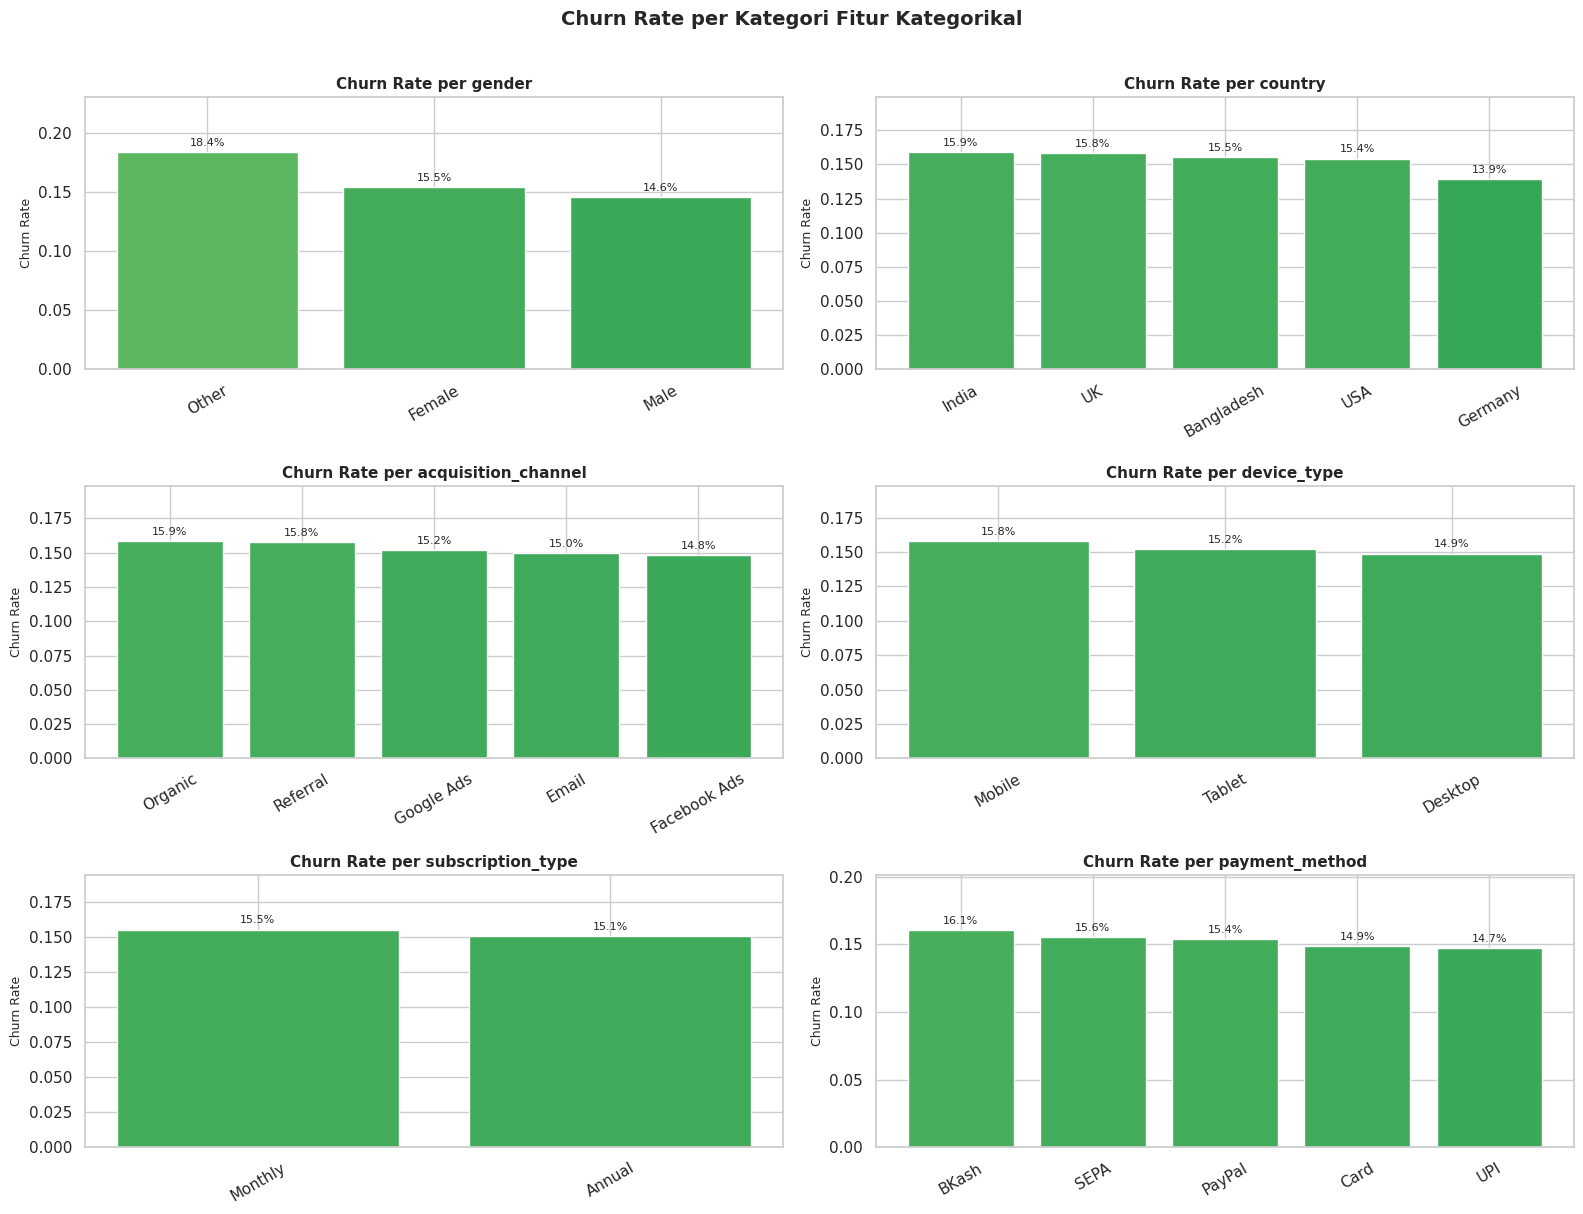

In [ ]:
# ANALISIS FITUR KATEGORIKAL vs CHURN
# Memahami bagaimana variabel kategorikal berhubungan dengan churn sebelum encoding


cat_cols = df.select_dtypes(include='object').columns.tolist()
# Hapus kolom date dan id yang tidak informatif untuk visualisasi ini
cat_plot_cols = [c for c in cat_cols if c not in
                 ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code', 'city']]

n_cols = 2
n_rows = (len(cat_plot_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    ax = axes[i]
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values,
                  color=plt.cm.RdYlGn_r(churn_rate.values), edgecolor='white')
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.1%}', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Churn Rate per {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Churn Rate', fontsize=9)
    ax.set_ylim(0, max(churn_rate.values) * 1.25)
    ax.tick_params(axis='x', rotation=30)

for j in range(len(cat_plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate per Kategori Fitur Kategorikal',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_categorical_churnrate.png', dpi=150, bbox_inches='tight')
plt.show()

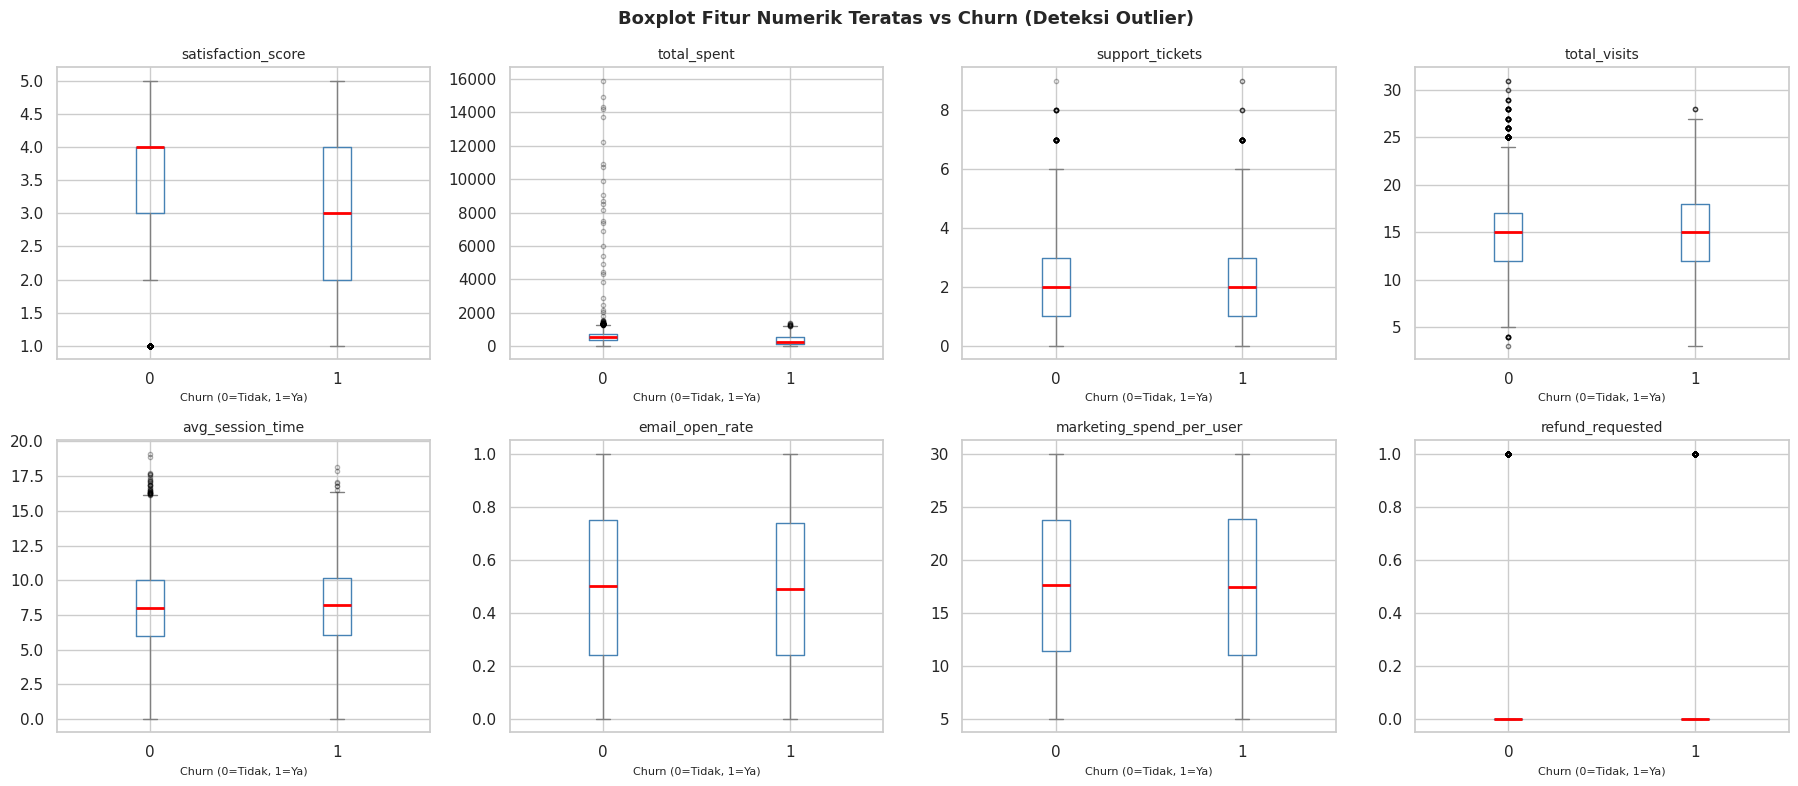

In [ ]:

# BOXPLOT — DETEKSI OUTLIER
# Outlier dapat mempengaruhi performa model linear (Logistic Regression, KNN) secara signifikan.
# Random Forest lebih robust terhadap outlier.

top_num_cols = corr_target.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(top_num_cols):
    ax = axes[i]
    df.boxplot(column=col, by='churn', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='gray'),
               capprops=dict(color='gray'),
               flierprops=dict(marker='o', color='orange', alpha=0.3, markersize=3))
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Churn (0=Tidak, 1=Ya)', fontsize=8)
    plt.sca(ax)
    plt.title(col, fontsize=10)

plt.suptitle('Boxplot Fitur Numerik Teratas vs Churn (Deteksi Outlier)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
# **2. DIRECT MODELING (Tanpa Preprocessing)**

> Membangun model dasar dan menghasilkan prediksi awal



2.1 Persiapan Data & 2.2 Train-test split

In [ ]:
# Identifikasi kolom untuk digunakan
drop_direct = ['customer_id', 'signup_date', 'last_purchase_date',
               'gender', 'country', 'city', 'acquisition_channel',
               'device_type', 'subscription_type', 'coupon_code',
               'payment_method']  # Drop kolom object/datetime

df_direct = df.drop(columns=drop_direct).copy()

# Isi missing value dengan median (paling minimal)
df_direct = df_direct.fillna(df_direct.median(numeric_only=True))

X_direct = df_direct.drop('churn', axis=1)
y_direct = df_direct['churn']

print(f'Fitur prediktor (X): {X_direct.shape[1]} kolom')
print(f'Sampel data         : {X_direct.shape[0]:,} baris')
print(f'Kolom yang digunakan: {list(X_direct.columns)}')

X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X_direct, y_direct,
    test_size=0.2,
    random_state=42,
    stratify=y_direct  # ← KUNCI: jaga proporsi kelas!
)

print(f'\n Train-Test Split (80:20 dengan stratify):')
print(f'   Training set : {X_train_dir.shape[0]:,} baris')
print(f'   Test set     : {X_test_dir.shape[0]:,} baris')
print(f'   Distribusi churn di train: {y_train_dir.mean():.2%}')
print(f'   Distribusi churn di test : {y_test_dir.mean():.2%}')

Fitur prediktor (X): 18 kolom
Sampel data         : 15,000 baris
Kolom yang digunakan: ['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']

 Train-Test Split (80:20 dengan stratify):
   Training set : 12,000 baris
   Test set     : 3,000 baris
   Distribusi churn di train: 15.32%
   Distribusi churn di test : 15.33%


Hanya menggunakan kolom numerik, drop kolom string/tanggal

Alasan: Direct = seminimal mungkin intervensi. Kita hanya drop kolom yang menyebabkan error (non-numeric)



---


TRAIN-TEST SPLIT

Alasan memilih 80:20:
- Dengan 15.000 data, 20% test = 3.000 sampel : cukup representatif
- 80% train = 12.000 sampel : cukup untuk generalisasi
- stratify=y: memastikan proporsi churn sama di train & test (penting untuk imbalanced dataset)
- random_state=42: reproducibility

2.3 Memilih model & 2.4 Melatih model

In [ ]:
model_lr  = LogisticRegression(max_iter=1000, random_state=42)
model_rf  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_knn = KNeighborsClassifier(n_neighbors=5)
model_svm = SVC(kernel='rbf', probability=True, random_state=42)

model_voting = VotingClassifier(
    estimators=[
        ('lr',  model_lr),
        ('rf',  RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ],
    voting='hard'   # Hard voting: mayoritas vote
    # 'soft' voting lebih baik jika model memberikan probabilitas kalibrasi baik
)

models_direct = {
    'Logistic Regression (Konvensional)'  : model_lr,
    'Random Forest (Ensemble Bagging)'    : model_rf,
    'Voting Classifier (Ensemble Voting)' : model_voting
}

print('3 Model telah didefinisikan:')
for name in models_direct:
    print(f'   • {name}')

3 Model telah didefinisikan:
   • Logistic Regression (Konvensional)
   • Random Forest (Ensemble Bagging)
   • Voting Classifier (Ensemble Voting)


MODEL 1 — LOGISTIC REGRESSION (Konvensional)

Alasan:
- Model baseline klasik untuk klasifikasi biner
- Interpretable: koefisien menunjukkan pengaruh fitur
- Efisien secara komputasi
- Cocok jika hubungan fitur-target bersifat linear
- Kelemahan: sensitif terhadap outlier & multikolinearitas

MODEL 2 — RANDOM FOREST (Ensemble Bagging)

Alasan:
- Ensemble dari banyak Decision Tree -> mengurangi variance
- Robust terhadap outlier dan missing value
- Memberikan feature importance secara otomatis
- Tidak memerlukan normalisasi fitur
- Performa terbaik untuk tabular data tanpa preprocessing
- Bagging: setiap tree dilatih pada subsampel data berbeda

MODEL 3 — VOTING CLASSIFIER (Ensemble Voting)

Alasan:
- Menggabungkan keunggulan LR + RF + KNN
- Voting hard: prediksi berdasarkan suara mayoritas
- Lebih stabil dari model tunggal
- Diversitas model (linear + non-linear + distance-based) meningkatkan robustness prediksi


2.5 Evaluasi Model


DIRECT | MODEL: Logistic Regression (Konvensional)
  Accuracy  : 0.8437  (84.37%)
  Precision : 0.4667
  Recall    : 0.1370  ← Paling penting untuk bisnis!
  F1-Score  : 0.2118

  Classification Report:
               precision    recall  f1-score   support

Non-Churn (0)       0.86      0.97      0.91      2540
    Churn (1)       0.47      0.14      0.21       460

     accuracy                           0.84      3000
    macro avg       0.66      0.55      0.56      3000
 weighted avg       0.80      0.84      0.81      3000



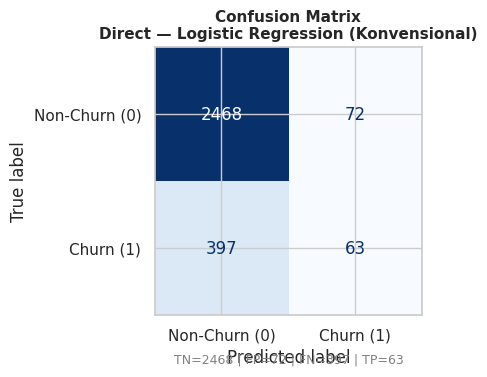


DIRECT | MODEL: Random Forest (Ensemble Bagging)
  Accuracy  : 0.8470  (84.70%)
  Precision : 0.5015
  Recall    : 0.3696  ← Paling penting untuk bisnis!
  F1-Score  : 0.4255

  Classification Report:
               precision    recall  f1-score   support

Non-Churn (0)       0.89      0.93      0.91      2540
    Churn (1)       0.50      0.37      0.43       460

     accuracy                           0.85      3000
    macro avg       0.70      0.65      0.67      3000
 weighted avg       0.83      0.85      0.84      3000



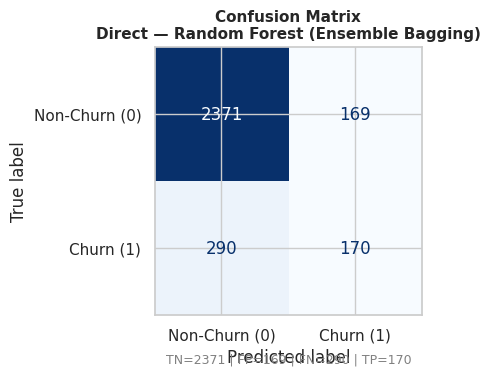


DIRECT | MODEL: Voting Classifier (Ensemble Voting)
  Accuracy  : 0.8490  (84.90%)
  Precision : 0.5248
  Recall    : 0.1609  ← Paling penting untuk bisnis!
  F1-Score  : 0.2463

  Classification Report:
               precision    recall  f1-score   support

Non-Churn (0)       0.86      0.97      0.92      2540
    Churn (1)       0.52      0.16      0.25       460

     accuracy                           0.85      3000
    macro avg       0.69      0.57      0.58      3000
 weighted avg       0.81      0.85      0.81      3000



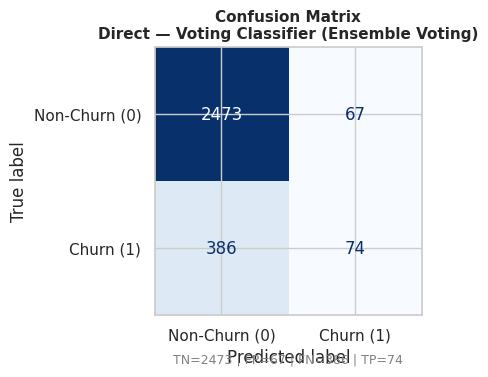

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, scenario=''):
    """Train model, evaluasi, dan tampilkan hasil lengkap."""
    # Training
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrik
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='binary', zero_division=0)

    # Tampilan
    print(f'\n{'='*65}')
    print(f'{scenario.upper()} | MODEL: {model_name}')
    print(f'{'='*65}')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}  ← Paling penting untuk bisnis!')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_test, y_pred,
                                target_names=['Non-Churn (0)', 'Churn (1)']))

    # Confusion Matrix
    cm   = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Non-Churn (0)', 'Churn (1)'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix\n{scenario} — {model_name}', fontsize=11, fontweight='bold')
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.18,
            f'TN={tn} | FP={fp} | FN={fn} | TP={tp}',
            ha='center', transform=ax.transAxes, fontsize=9, color='gray')
    plt.tight_layout()
    fname = f'cm_{scenario.lower().replace(" ","_")}_{model_name.lower().replace(" ","_")[:15]}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    return {'model': model_name, 'scenario': scenario,
            'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


# LATIH DAN EVALUASI — DIRECT MODELING

results_direct = []

for name, model in models_direct.items():
    result = evaluate_model(
        model, X_train_dir, X_test_dir, y_train_dir, y_test_dir,
        model_name=name, scenario='Direct'
    )
    results_direct.append(result)


 RINGKASAN PERFORMA — DIRECT MODELING
                              model  accuracy  precision   recall       f1
 Logistic Regression (Konvensional)  0.843667   0.466667 0.136957 0.211765
   Random Forest (Ensemble Bagging)  0.847000   0.501475 0.369565 0.425532
Voting Classifier (Ensemble Voting)  0.849000   0.524823 0.160870 0.246256


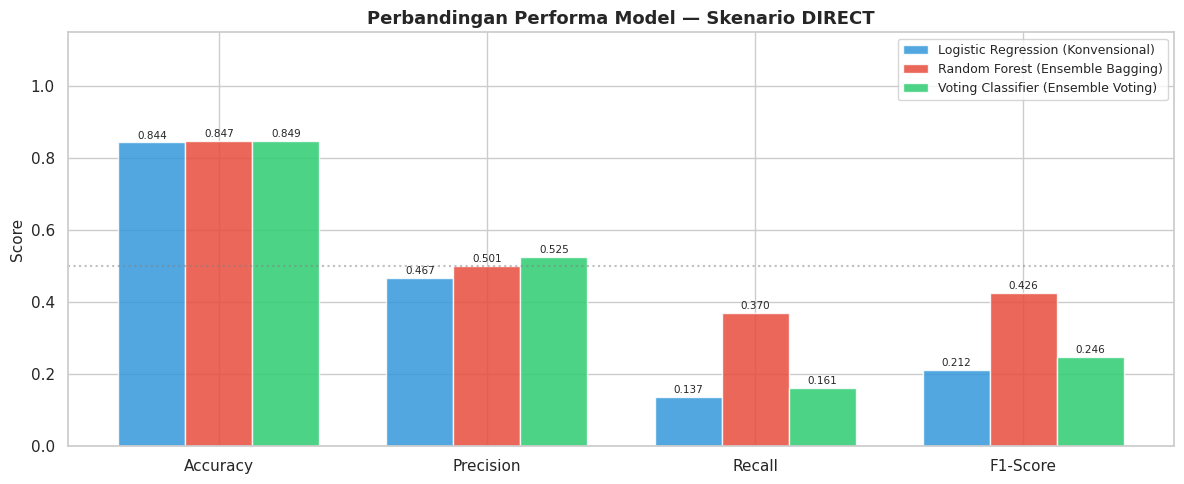

In [ ]:
# Tabel ringkasan Direct Modeling
df_results_direct = pd.DataFrame(results_direct)
print('\n RINGKASAN PERFORMA — DIRECT MODELING')
print(df_results_direct[['model','accuracy','precision','recall','f1']].to_string(index=False))

# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(12, 5))
metrics = ['accuracy', 'precision', 'recall', 'f1']
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['#3498db', '#e74c3c', '#2ecc71']

for i, (_, row) in enumerate(df_results_direct.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=row['model'],
                  color=colors[i], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005, f'{val:.3f}',
                ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'], fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title('Perbandingan Performa Model — Skenario DIRECT', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('comparison_direct.png', dpi=150, bbox_inches='tight')
plt.show()

# **3. MODELING DENGAN PREPROCESSING**


> Membangun model dan menghasilkan prediksi dengan data yang bersih


3.1 Preprocessing data

1. Penanganan missing value

In [ ]:
# Missing value
df_clean = df.copy()
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
n_after  = len(df_clean)
print(f'Duplikasi: {n_before - n_after} baris dihapus ({(n_before-n_after)/n_before*100:.2f}%)')

Duplikasi: 0 baris dihapus (0.00%)


2. Fiture Engineering - Ekstrak Fitur dari Tanggal

In [ ]:
reference_date = pd.Timestamp('2025-01-01')  # Tanggal referensi

df_clean['signup_date']        = pd.to_datetime(df_clean['signup_date'], errors='coerce')
df_clean['last_purchase_date'] = pd.to_datetime(df_clean['last_purchase_date'], errors='coerce')

df_clean['days_since_signup']   = (reference_date - df_clean['signup_date']).dt.days
df_clean['days_since_purchase'] = (reference_date - df_clean['last_purchase_date']).dt.days
df_clean['customer_tenure_years'] = df_clean['days_since_signup'] / 365

# Drop kolom tanggal asli setelah diekstrak
df_clean = df_clean.drop(columns=['signup_date', 'last_purchase_date', 'customer_id'])

print('  Feature Engineering Tanggal:')
print('   • days_since_signup   : lama sejak pertama daftar')
print('   • days_since_purchase : lama sejak transaksi terakhir (sinyal churn!)')
print('   • customer_tenure_years: lama berlangganan dalam tahun')
print(f'   Kolom baru total: {df_clean.shape[1]}')

  Feature Engineering Tanggal:
   • days_since_signup   : lama sejak pertama daftar
   • days_since_purchase : lama sejak transaksi terakhir (sinyal churn!)
   • customer_tenure_years: lama berlangganan dalam tahun
   Kolom baru total: 30


Alasan :
Tanggal mentah tidak berarti untuk model ML. Turunannya (lama berlangganan, hari sejak pembelian terakhir) jurstru memiliki nilai prediktif tinggi utk churn. Pelanggan lama yg tidak membeli = sinyal churn kuat

3. Handle Missing Value
- Numerik : Mediann (robust terhadap outlier vs median) Alasan pilih median bukan mean = jika data skewed, median lebih representatif

- Kategorikal : Mode (nilai paling sering muncul) Alternatif: buat kategori 'unknown' supaya lebih aman jika presentase missing tinggi (>20%)


In [ ]:
num_cols_pp  = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_pp  = df_clean.select_dtypes(include='object').columns.tolist()

# Pisahkan target sebelum impute (hindari data leakage)
X_temp = df_clean.drop('churn', axis=1)
y_temp = df_clean['churn']

num_features = X_temp.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_temp.select_dtypes(include='object').columns.tolist()

# Impute numerik dengan median
for col in num_features:
    median_val = X_temp[col].median()
    X_temp[col] = X_temp[col].fillna(median_val)

# Impute kategorikal dengan mode
for col in cat_features:
    mode_val = X_temp[col].mode()[0] if not X_temp[col].mode().empty else 'Unknown'
    X_temp[col] = X_temp[col].fillna(mode_val)

print(f'Missing Value setelah imputasi: {X_temp.isnull().sum().sum()}')

Missing Value setelah imputasi: 0


4. Handle Outlier -  IQR Capping (Winsorization)

Alasan :
-  Outlier ekstrem bisa mendominasi model seperti LR dan KNN
- IQR Capping (bukan penghapusan): cap nilai di [Q1-1.5*IQR, Q3+1.5*IQR]
- Kenapa capping bukan hapus? Mempertahankan jumlah data, hanya mengurangi dampak nilai ekstrem
- Random Forest lebih robust tapi capping tetap membantu konsistensi

In [ ]:
# Hanya terapkan pada fitur numerik yang memiliki potensi outlier
skewed_cols = []
for col in num_features:
    skew = X_temp[col].skew()
    if abs(skew) > 1.5:  # Threshold skewness
        skewed_cols.append(col)

print(f'Kolom dengan skewness tinggi (|skew| > 1.5): {len(skewed_cols)} kolom')
print(skewed_cols)

for col in skewed_cols:
    Q1  = X_temp[col].quantile(0.25)
    Q3  = X_temp[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X_temp[col] = X_temp[col].clip(lower=lower_bound, upper=upper_bound)

print(f'Outlier capping selesai pada {len(skewed_cols)} kolom skewed')

Kolom dengan skewness tinggi (|skew| > 1.5): 0 kolom
[]
Outlier capping selesai pada 0 kolom skewed


5. Encoding Fitur Kategorikal

Strategi:
-  Binary features (2 nilai unik): Label Encoding (0/1)
- Nominal features (>2 nilai, tidak ada urutan): One-Hot Encoding. Alasan: Mencegah model menginterpretasikan urutan yang tidak ada
- Ordinal features (ada urutan): Manual mapping atau LabelEncoder.
- coupon_code & city: High cardinality -> Label Encoding (OHE akan membuat terlalu banyak kolom)

In [ ]:
print('Kolom kategorikal:', cat_features)

# Ordinal encoding manual
if 'subscription_type' in cat_features:
    sub_map = {'Monthly': 0, 'Annual': 1}
    X_temp['subscription_type'] = X_temp['subscription_type'].map(sub_map).fillna(0)
    cat_features.remove('subscription_type')
    print('✅ subscription_type: Ordinal encoding (Basic=0, Standard=1, Premium=2)')

# One-Hot Encoding untuk nominal dengan kardinality rendah
low_card_cats = [c for c in cat_features
                 if c not in ['coupon_code', 'city', 'country']
                 and X_temp[c].nunique() <= 10]

X_encoded = pd.get_dummies(X_temp, columns=low_card_cats, drop_first=True)
print(f'✅ One-Hot Encoding pada: {low_card_cats}')

# Label Encoding untuk high-cardinality
le = LabelEncoder()
remaining_cats = [c for c in X_encoded.select_dtypes(include='object').columns]
for col in remaining_cats:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    print(f'✅ Label Encoding pada: {col} ({X_encoded[col].nunique()} kategori)')

X_encoded = X_encoded.astype(float)
print(f'\n📋 Shape setelah encoding: {X_encoded.shape}')

Kolom kategorikal: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'coupon_code', 'payment_method']
✅ One-Hot Encoding pada: ['gender', 'acquisition_channel', 'device_type', 'payment_method']
✅ Label Encoding pada: country (5 kategori)
✅ Label Encoding pada: city (7 kategori)
✅ Label Encoding pada: coupon_code (3 kategori)

📋 Shape setelah encoding: (15000, 37)


In [ ]:
df.head(10)

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0
5,10006,Male,29.0,Germany,Mumbai,2024-05-08 00:00:00,2023-01-20 00:00:00,Google Ads,Mobile,Monthly,...,2,0,2,SEPA,3.0,10,16.30,467.452413,14,0
6,10007,Male,39.0,UK,New York,2022-01-04 00:00:00,2023-12-05 00:00:00,Email,Mobile,Monthly,...,0,0,3,Card,5.0,10,29.76,1697.386983,1,0
7,10008,Female,NaN,Germany,Berlin,2023-05-11 00:00:00,2024-02-14 00:00:00,Facebook Ads,Desktop,Annual,...,2,0,0,SEPA,3.0,5,18.86,1337.967629,6,0
8,10009,Female,21.0,USA,London,2023-01-14 00:00:00,2024-08-19 00:00:00,Organic,Desktop,Monthly,...,3,0,5,Card,4.0,7,27.14,648.012150,2,1
9,10010,Female,35.0,Germany,Hamburg,2022-12-22 00:00:00,2024-09-04 00:00:00,Email,Tablet,Monthly,...,0,0,3,SEPA,3.0,7,5.22,1360.483364,9,1


In [ ]:
X_temp.head(10)


,gender,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,...,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,days_since_signup,days_since_purchase,customer_tenure_years
0,Male,52.0,India,Berlin,Email,Tablet,0.0,1,7,13.903745,...,3,UPI,3.0,10,27.56,915.310827,14,967,1,2.649315
1,Male,35.0,Germany,Mumbai,Organic,Desktop,0.0,0,19,5.112528,...,3,BKash,3.0,7,15.15,2079.960938,11,199,239,0.545205
2,Female,27.0,Germany,London,Email,Mobile,0.0,1,18,9.742749,...,2,UPI,5.0,6,13.51,1379.150885,9,497,248,1.361644
3,Female,36.0,India,Mumbai,Facebook Ads,Tablet,0.0,1,16,9.642654,...,2,PayPal,4.0,6,25.65,774.652684,7,339,592,0.928767
4,Male,29.0,USA,Hamburg,Referral,Mobile,0.0,0,12,7.791291,...,4,BKash,3.0,1,12.39,87.680409,11,530,269,1.452055
5,Male,29.0,Germany,Mumbai,Google Ads,Mobile,0.0,0,13,13.266709,...,2,SEPA,3.0,10,16.30,467.452413,14,238,712,0.652055
6,Male,39.0,UK,New York,Email,Mobile,0.0,0,15,7.631444,...,3,Card,5.0,10,29.76,1697.386983,1,1093,393,2.994521
7,Female,35.0,Germany,Berlin,Facebook Ads,Desktop,0.0,0,15,9.994333,...,0,SEPA,3.0,5,18.86,1337.967629,6,601,322,1.646575
8,Female,21.0,USA,London,Organic,Desktop,0.0,1,10,11.407998,...,5,Card,4.0,7,27.14,648.012150,2,718,135,1.967123
9,Female,35.0,Germany,Hamburg,Email,Tablet,0.0,0,14,7.434829,...,3,SEPA,3.0,7,5.22,1360.483364,9,741,119,2.030137


In [ ]:
X_encoded.head(10)


,age,country,city,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,...,acquisition_channel_Facebook Ads,acquisition_channel_Google Ads,acquisition_channel_Organic,acquisition_channel_Referral,device_type_Mobile,device_type_Tablet,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI
0,52.0,2.0,0.0,0.0,1.0,7.0,13.903745,5.415164,0.67,0.26,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,35.0,1.0,5.0,0.0,0.0,19.0,5.112528,5.352441,0.70,0.37,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,27.0,1.0,4.0,0.0,1.0,18.0,9.742749,3.594719,0.47,0.44,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,36.0,2.0,5.0,0.0,1.0,16.0,9.642654,2.949531,0.58,0.37,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,29.0,4.0,3.0,0.0,0.0,12.0,7.791291,2.405539,0.05,0.16,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
5,29.0,1.0,5.0,0.0,0.0,13.0,13.266709,2.883520,0.12,0.33,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6,39.0,3.0,6.0,0.0,0.0,15.0,7.631444,2.235899,0.57,0.45,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
7,35.0,1.0,0.0,0.0,0.0,15.0,9.994333,5.892048,0.96,0.46,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,21.0,4.0,4.0,0.0,1.0,10.0,11.407998,4.592771,0.99,0.22,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9,35.0,1.0,3.0,0.0,0.0,14.0,7.434829,2.682819,0.03,0.46,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


### **ini masih ada salah yg di bagian encoding, next perbaikin**


In [ ]:
X_train_pp, X_test_pp, y_train_pp, y_test_pp = train_test_split(
    X_encoded, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

print(f'Train-Test Split: {X_train_pp.shape[0]:,} train | {X_test_pp.shape[0]:,} test')

✅ Train-Test Split: 12,000 train | 3,000 test


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pp)   # fit + transform
X_test_scaled  = scaler.transform(X_test_pp)         # hanya transform!

# Konversi kembali ke DataFrame untuk kemudahan
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_encoded.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_encoded.columns)

print('Scaling selesai (fit on train only, transform both)')
print(f'   Mean fitur di train (setelah scaling): ~{X_train_scaled.mean().mean():.4f}')
print(f'   Std  fitur di train (setelah scaling): ~{X_train_scaled.std().mean():.4f}')

✅ Scaling selesai (fit on train only, transform both)
   Mean fitur di train (setelah scaling): ~-0.0000
   Std  fitur di train (setelah scaling): ~0.9460


In [ ]:
print('Distribusi SEBELUM SMOTE:')
print(f'  Non-Churn: {(y_train_pp == 0).sum():,} | Churn: {(y_train_pp == 1).sum():,}')

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_pp)

print('\nDistribusi SETELAH SMOTE:')
print(f'  Non-Churn: {(y_train_smote == 0).sum():,} | Churn: {(y_train_smote == 1).sum():,}')
print(f' Rasio kelas sekarang: {(y_train_smote == 0).sum() / (y_train_smote == 1).sum():.2f}:1')
print(' Catatan: Test set TIDAK di-SMOTE — tetap distribusi asli!')

Distribusi SEBELUM SMOTE:
  Non-Churn: 10,162 | Churn: 1,838

Distribusi SETELAH SMOTE:
  Non-Churn: 10,162 | Churn: 10,162
 Rasio kelas sekarang: 1.00:1
 Catatan: Test set TIDAK di-SMOTE — tetap distribusi asli!



PREPROCESSING | MODEL: Logistic Regression (Konvensional)
  Accuracy  : 0.7603  (76.03%)
  Precision : 0.3600
  Recall    : 0.7239  ← Paling penting untuk bisnis!
  F1-Score  : 0.4809

  Classification Report:
               precision    recall  f1-score   support

Non-Churn (0)       0.94      0.77      0.84      2540
    Churn (1)       0.36      0.72      0.48       460

     accuracy                           0.76      3000
    macro avg       0.65      0.75      0.66      3000
 weighted avg       0.85      0.76      0.79      3000



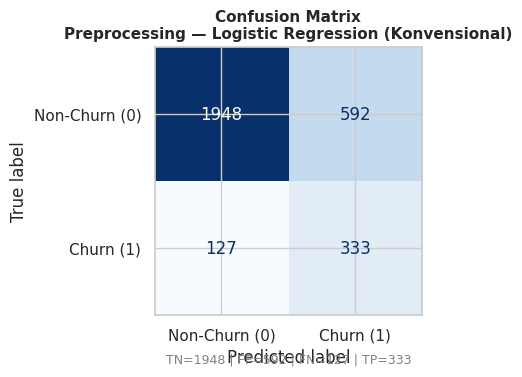


PREPROCESSING | MODEL: Random Forest (Ensemble Bagging)
  Accuracy  : 0.8510  (85.10%)
  Precision : 0.5101
  Recall    : 0.7130  ← Paling penting untuk bisnis!
  F1-Score  : 0.5947

  Classification Report:
               precision    recall  f1-score   support

Non-Churn (0)       0.94      0.88      0.91      2540
    Churn (1)       0.51      0.71      0.59       460

     accuracy                           0.85      3000
    macro avg       0.73      0.79      0.75      3000
 weighted avg       0.88      0.85      0.86      3000



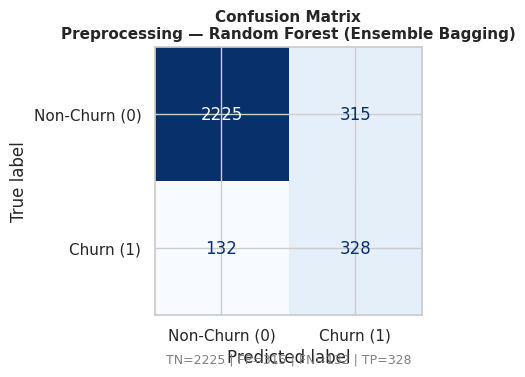


PREPROCESSING | MODEL: Voting Classifier (Ensemble Voting)
  Accuracy  : 0.8290  (82.90%)
  Precision : 0.4653
  Recall    : 0.7717  ← Paling penting untuk bisnis!
  F1-Score  : 0.5805

  Classification Report:
               precision    recall  f1-score   support

Non-Churn (0)       0.95      0.84      0.89      2540
    Churn (1)       0.47      0.77      0.58       460

     accuracy                           0.83      3000
    macro avg       0.71      0.81      0.74      3000
 weighted avg       0.88      0.83      0.84      3000



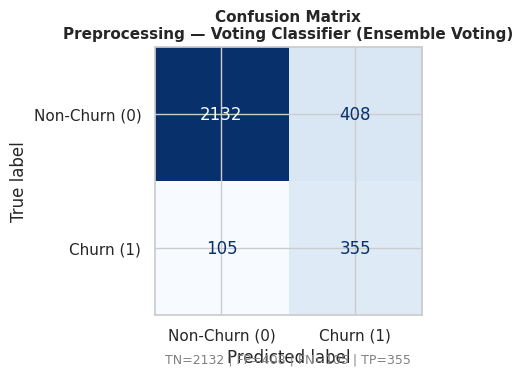

In [ ]:
model_lr_pp  = LogisticRegression(max_iter=1000, random_state=42)
model_rf_pp  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_voting_pp = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ],
    voting='soft'  # Soft voting: rata-rata probabilitas -> lebih akurat
)

models_pp = {
    'Logistic Regression (Konvensional)'  : model_lr_pp,
    'Random Forest (Ensemble Bagging)'    : model_rf_pp,
    'Voting Classifier (Ensemble Voting)' : model_voting_pp
}

results_pp = []
for name, model in models_pp.items():
    result = evaluate_model(
        model, X_train_smote, X_test_scaled, y_train_smote, y_test_pp,
        model_name=name, scenario='Preprocessing'
    )
    results_pp.append(result)